In [11]:
import pandas as pd

In [12]:
import numpy as np

In [13]:
df = pd.read_csv("../data/transactions.scv")
df

,transaction_id,amount,new_device,unusual_location,night,fraud
0,1,50,0,0,0,0
1,2,120,0,0,0,0
2,3,850,1,1,1,1
3,4,40,0,0,0,0
4,5,900,1,1,0,1
5,6,75,0,0,1,0
6,7,1200,1,1,1,1
7,8,60,0,0,0,0
8,9,700,1,0,1,1
9,10,100,0,0,0,0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   transaction_id    10 non-null     int64
 1   amount            10 non-null     int64
 2   new_device        10 non-null     int64
 3   unusual_location  10 non-null     int64
 4   night             10 non-null     int64
 5   fraud             10 non-null     int64
dtypes: int64(6)
memory usage: 612.0 bytes


In [15]:
df.describe()

,transaction_id,amount,new_device,unusual_location,night,fraud
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,409.500000,0.400000,0.300000,0.400000,0.400000
std,3.02765,450.101532,0.516398,0.483046,0.516398,0.516398
min,1.00000,40.000000,0.000000,0.000000,0.000000,0.000000
25%,3.25000,63.750000,0.000000,0.000000,0.000000,0.000000
50%,5.50000,110.000000,0.000000,0.000000,0.000000,0.000000
75%,7.75000,812.500000,1.000000,0.750000,1.000000,1.000000
max,10.00000,1200.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
df["fraud"].value_counts()

fraud
0    6
1    4
Name: count, dtype: int64

In [18]:
p_fraud = df["fraud"].mean()
print(f"P(Fraud) = {p_fraud:.2%}")
print(p_fraud)

P(Fraud) = 40.00%
0.4


In [19]:
fraud_given_new_device = df.groupby("new_device")["fraud"].mean()
print(fraud_given_new_device)

new_device
0    0.0
1    1.0
Name: fraud, dtype: float64


In [20]:
p_fraud_given_new_device = (
    df[df["new_device"] == 1]["fraud"].mean()
)
print(f"P(Fraud | New Device) = {p_fraud_given_new_device:.2%}")


P(Fraud | New Device) = 100.00%


In [21]:
p_fraud_given_unusual_location = (
    df[df["unusual_location"] == 1]["fraud"].mean()
)

print(
    f"P(Fraud | Unusual Location) = "
    f"{p_fraud_given_unusual_location:.2%}"
)

P(Fraud | Unusual Location) = 100.00%


In [22]:
p_fraud_given_night = (
    df[df["night"] == 1]["fraud"].mean()
)

print(f"P(Fraud | Night) = {p_fraud_given_night:.2%}")

P(Fraud | Night) = 75.00%


In [23]:
p_fraud = df["fraud"].mean()

p_new_device_given_fraud = (
    df[df["fraud"] == 1]["new_device"].mean()
)

p_new_device = df["new_device"].mean()

p_fraud_given_new_device = (
    p_new_device_given_fraud * p_fraud
) / p_new_device

print(f"P(Fraud) = {p_fraud:.2%}")
print(
    f"P(New Device | Fraud) = "
    f"{p_new_device_given_fraud:.2%}"
)
print(f"P(New Device) = {p_new_device:.2%}")
print(
    f"P(Fraud | New Device) = "
    f"{p_fraud_given_new_device:.2%}"
)

P(Fraud) = 40.00%
P(New Device | Fraud) = 100.00%
P(New Device) = 40.00%
P(Fraud | New Device) = 100.00%


In [24]:
new_transaction = {
    "amount": 950,
    "new_device": 1,
    "unusual_location": 1,
    "night": 1
}

print(new_transaction)

{'amount': 950, 'new_device': 1, 'unusual_location': 1, 'night': 1}


In [25]:
risk_score = 0

if new_transaction["new_device"] == 1:
    risk_score += 1

if new_transaction["unusual_location"] == 1:
    risk_score += 1

if new_transaction["night"] == 1:
    risk_score += 1

print(f"Risk Score: {risk_score}/3")

Risk Score: 3/3


In [26]:
if risk_score >= 2:
    print("⚠️ High Risk Transaction")
else:
    print("✅ Low Risk Transaction")

⚠️ High Risk Transaction


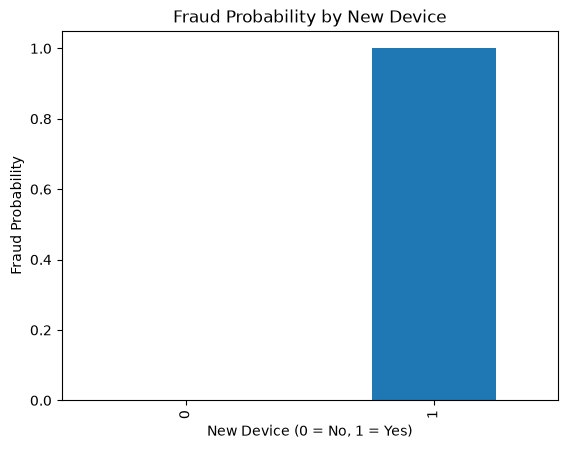

In [ ]:
import matplotlib.pyplot as plt

df.groupby("new_device")["fraud"].mean().plot(
    kind="bar"
)

plt.title("Fraud Probability by New Device") # type: ignore
plt.xlabel("New Device (0 = No, 1 = Yes)")
plt.ylabel("Fraud Probability")
plt.show()

In [28]:
import sys

sys.path.append("../src")

from gradient_descent import (
    calculate_prediction,
    calculate_loss,
    calculate_gradient,
    update_weight
)

In [29]:
x = 2
target = 10

weight = 1
learning_rate = 0.1

In [30]:
for step in range(10):

    # Forward pass
    prediction = calculate_prediction(x, weight)

    # Calculate loss
    loss = calculate_loss(prediction, target)

    # Calculate gradient
    gradient = calculate_gradient(
        x,
        prediction,
        target
    )

    # Update weight
    weight = update_weight(
        weight,
        learning_rate,
        gradient
    )

    print(
        f"Step {step + 1}: "
        f"prediction={prediction:.2f}, "
        f"loss={loss:.2f}, "
        f"gradient={gradient:.2f}, "
        f"weight={weight:.2f}"
    )

Step 1: prediction=2.00, loss=64.00, gradient=-32.00, weight=4.20
Step 2: prediction=8.40, loss=2.56, gradient=-6.40, weight=4.84
Step 3: prediction=9.68, loss=0.10, gradient=-1.28, weight=4.97
Step 4: prediction=9.94, loss=0.00, gradient=-0.26, weight=4.99
Step 5: prediction=9.99, loss=0.00, gradient=-0.05, weight=5.00
Step 6: prediction=10.00, loss=0.00, gradient=-0.01, weight=5.00
Step 7: prediction=10.00, loss=0.00, gradient=-0.00, weight=5.00
Step 8: prediction=10.00, loss=0.00, gradient=-0.00, weight=5.00
Step 9: prediction=10.00, loss=0.00, gradient=-0.00, weight=5.00
Step 10: prediction=10.00, loss=0.00, gradient=-0.00, weight=5.00


In [31]:
weights = []
losses = []

weight = 1.0

for step in range(20):

    prediction = calculate_prediction(x, weight)

    loss = calculate_loss(
        prediction,
        target
    )

    gradient = calculate_gradient(
        x,
        prediction,
        target
    )

    weight = update_weight(
        weight,
        learning_rate,
        gradient
    )

    weights.append(weight)
    losses.append(loss)

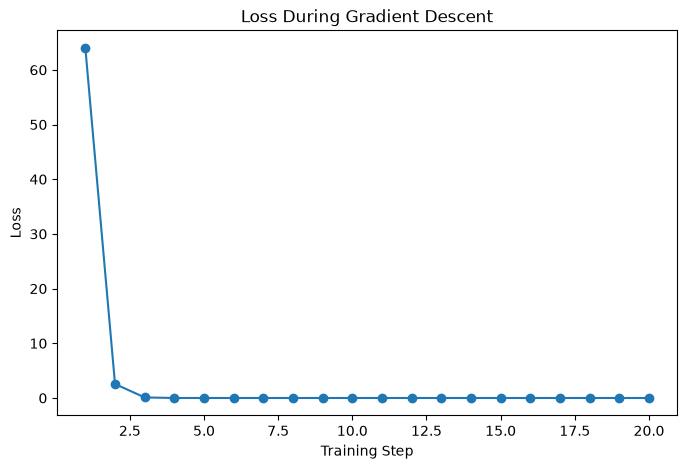

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(losses) + 1),
    losses,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss During Gradient Descent")

plt.show()